In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

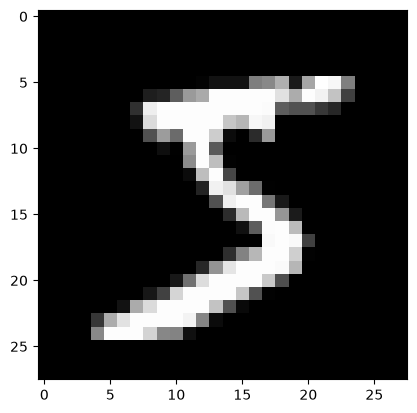

In [8]:
plt.imshow(X_train[0], cmap='gray')

In [ ]:
# its 28 by 28 pixel images of hand written numbers. Each image is represented as a 2D array of pixel values. The shape of X_train is (60000, 28, 28), which means there are 60,000 training images, each of size 28x28 pixels.


In [9]:
# first we need to scale the pixel values to be between 0 and 1. We can do this by dividing the pixel values by 255, which is the maximum pixel value.

In [10]:
X_train = X_train / 255
X_test = X_test / 255

In [20]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28))) # we are Flattening the 2D array of pixel values into a 1D array of 784 pixel values. This is because the Dense layer expects a 1D array as input.
model.add(Dense(128, activation='relu')) # we are adding a Dense layer with 128 neurons and relu activation function. The relu activation function is used to introduce non-linearity into the model. This allows the model to learn more complex patterns in the data.
model.add(Dense(64, activation='relu')) # we are adding another Dense layer with 64 neurons and relu activation function. This allows the model to learn more complex patterns in the data.
model.add(Dense(10, activation='softmax')) # we are adding a Dense layer with 10 neurons and softmax activation function. The softmax activation function is used to convert the output of the model into a probability distribution over the 10 classes (0-9). This allows us to interpret the output of the model as the probability of each class.

d:\whole ML\mlvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9229 - loss: 0.2698 - val_accuracy: 0.9596 - val_loss: 0.1384
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9661 - loss: 0.1118 - val_accuracy: 0.9668 - val_loss: 0.1065
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9756 - loss: 0.0782 - val_accuracy: 0.9709 - val_loss: 0.0973
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9815 - loss: 0.0583 - val_accuracy: 0.9723 - val_loss: 0.0925
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9856 - loss: 0.0452 - val_accuracy: 0.9758 - val_loss: 0.0850
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9885 - loss: 0.0351 - val_accuracy: 0.9747 - val_loss: 0.0916
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9903 - loss: 0.0303 - val_accuracy: 0.9718 - val_loss: 0.1075
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9918 - loss: 0.0253 - 

In [16]:
model.layers[1].get_weights()

[array([[ 0.03185434,  0.01010271,  0.06710351, ...,  0.07405754,
          0.02835975,  0.07674036],
        [ 0.00454773, -0.04548977, -0.03525179, ..., -0.06652772,
         -0.07851703,  0.02060246],
        [ 0.07000468, -0.0393476 , -0.01443869, ...,  0.07328949,
          0.06768551, -0.02687658],
        ...,
        [-0.06313816, -0.04319896,  0.04813679, ..., -0.01317809,
         -0.01195706, -0.07602719],
        [-0.00219805,  0.06705869,  0.02299457, ..., -0.03735073,
         -0.00059102,  0.07377429],
        [ 0.04791259,  0.05776184, -0.07382116, ...,  0.05111257,
          0.04871725, -0.03776159]], shape=(784, 128), dtype=float32),
 array([-0.13481773, -0.03397657,  0.05998784, -0.06724077,  0.00939306,
         0.06162952,  0.02438445,  0.07110041,  0.12377784, -0.07564252,
        -0.02715781, -0.06172706, -0.01604852, -0.03632207,  0.01493373,
         0.14000933,  0.09719006,  0.13327038,  0.1572666 , -0.02043497,
        -0.01501012, -0.00164714,  0.04041797,  

In [27]:
y_prob = model.predict(X_test)
y_prob #this gives us the probability of each class for each image in the test set. The shape of y_prob is (10000, 10), which means there are 10,000 test images, and for each image, we have a probability distribution over the 10 classes.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step


array([[6.7367109e-19, 6.4105439e-16, 6.8947522e-13, ..., 1.0000000e+00,
        8.4357333e-23, 8.7494440e-17],
       [2.9787227e-17, 1.6102001e-19, 1.0000000e+00, ..., 1.4482976e-21,
        1.0069521e-14, 1.0526720e-28],
       [5.3565681e-12, 1.0000000e+00, 2.2199943e-11, ..., 3.1291473e-11,
        5.5527045e-11, 2.8759822e-12],
       ...,
       [3.7101990e-29, 2.4634883e-20, 7.8062625e-26, ..., 2.1617930e-17,
        3.2839929e-23, 2.8380715e-16],
       [1.5493214e-22, 8.6237058e-29, 6.1776640e-26, ..., 1.0089875e-19,
        9.0901328e-19, 3.4599601e-22],
       [1.0949846e-15, 4.0160762e-21, 1.5322055e-15, ..., 5.2297795e-31,
        1.7563398e-16, 9.8903690e-22]], shape=(10000, 10), dtype=float32)

In [28]:
y_pred  = y_prob.argmax(axis=1) # we are using the argmax function to get the index of the maximum value in each row of y_prob. This gives us the predicted class for each image in the test set. The shape of y_pred is (10000,), which means there are 10,000 predicted classes, one for each test image.

In [29]:
from sklearn.metrics import accuracy_score
acc =  accuracy_score(y_test, y_pred)
acc

0.9778

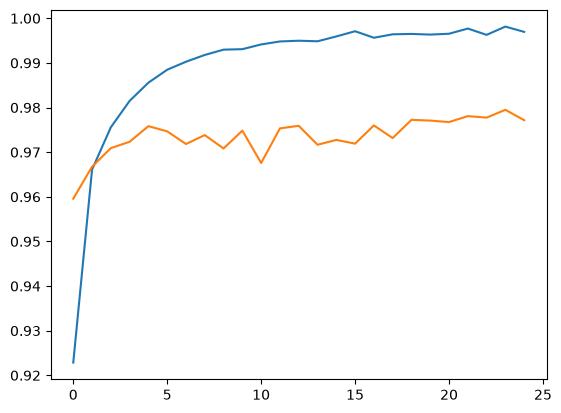

In [30]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')

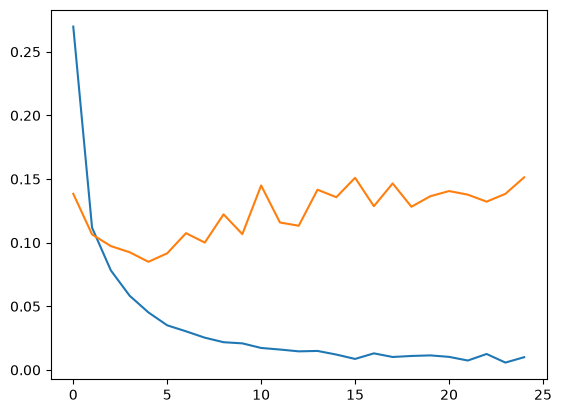

In [31]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')

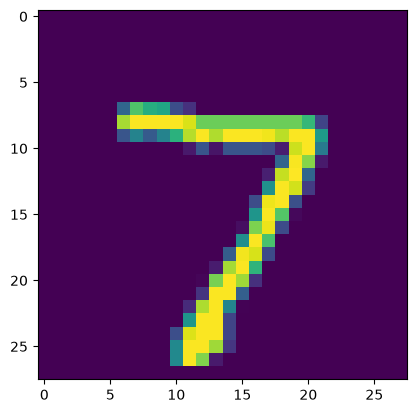

In [32]:
plt.imshow(X_test[0])

In [35]:
model.predict(X_test[0].reshape(1, 28, 28)).argmax() # we are using the reshape function to reshape the 2D array of pixel values into a 3D array of shape (1, 28, 28). This is because the model expects a 3D array as input. The first dimension is the batch size, which is 1 in this case. The second and third dimensions are the height and width of the image, which are both 28 pixels. We are then using the argmax function to get the index of the maximum value in the output of the model. This gives us the predicted class for the image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


np.int64(7)

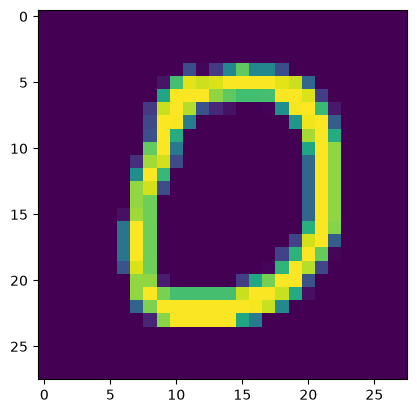

In [36]:
plt.imshow(X_test[10])


In [37]:
model.predict(X_test[10].reshape(1, 28, 28)).argmax() # we are using the reshape function to reshape the 2D array of pixel values into a 3D array of shape (1, 28, 28). This is because the model expects a 3D array as input. The first dimension is the batch size, which is 1 in this case. The second and third dimensions are the height and width of the image, which are both 28 pixels. We are then using the argmax function to get the index of the maximum value in the output of the model. This gives us the predicted class for the image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


np.int64(0)